In [3]:
import torch
import numpy as np
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

from opimizers.adamuon import AdaMuon
from opimizers.muon import Muon

device = "xpu" if torch.xpu.is_available() else "cpu"
print(device)

%config InlineBackend.figure_format = 'svg'

xpu


In [4]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.xpu.is_available():
        torch.xpu.manual_seed(seed)

In [5]:
class ResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.skip(x))

In [6]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1, bias=False),
                                  nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResNetBlock(32, 64, stride=2)
        self.layer2 = ResNetBlock(64, 128, stride=2)
        self.layer3 = ResNetBlock(128, 256, stride=2)
        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.mean(dim=(2, 3))
        return self.head(x)

In [7]:
def make_muon_optimizer(model, lr=1e-3):
    muon_params = [p for p in model.parameters()
                   if p.ndim >= 2 and p.requires_grad]
    adam_params = [p for p in model.parameters()
                   if p.ndim < 2 and p.requires_grad]
    return Muon([
        {"params": muon_params, "use_muon": True, "lr": lr},
        {"params": adam_params, "use_muon": False, "lr": lr},
    ])


def make_adamuon_optimizer(model, lr=1e-3):
    muon_params = [p for p in model.parameters()
                   if p.ndim >= 2 and p.requires_grad]
    adam_params = [p for p in model.parameters()
                   if p.ndim < 2 and p.requires_grad]
    return AdaMuon([
        {"params": muon_params, "use_muon": True, "lr": lr},
        {"params": adam_params, "use_muon": False, "lr": lr},
    ])


def make_adam_optimizer(model, lr=1e-3):
    return torch.optim.AdamW(model.parameters(), lr=lr,
                             betas=(0.9, 0.95))

In [8]:
def get_cifar10(batch_size=128):
    tfm_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    train = datasets.CIFAR10(
        "data", train=True,  download=True, transform=tfm_train)
    test = datasets.CIFAR10("data", train=False,
                            download=True, transform=tfm_test)
    return (DataLoader(train, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True),
            DataLoader(test,  batch_size=256, shuffle=False,
                       num_workers=2, pin_memory=True))

In [9]:
def get_cifar100(batch_size=128):
    tfm_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    train = datasets.CIFAR100(
        "data", train=True,  download=True, transform=tfm_train)
    test = datasets.CIFAR100("data", train=False,
                             download=True, transform=tfm_test)
    return (DataLoader(train, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True),
            DataLoader(test,  batch_size=256, shuffle=False,
                       num_workers=2, pin_memory=True))

In [10]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, n = 0., 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        res = model(x)
        loss = F.cross_entropy(res, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (res.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, correct / n

In [11]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, n = 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        n += len(y)
    return correct / n

In [12]:
dispatcher = {
    "muon": make_muon_optimizer,
    "adamuon": make_adamuon_optimizer,
    "adam": make_adam_optimizer,
}

In [13]:
def run(optimizer_name, num_classes=10, epochs=20, device="cpu"):
    set_seed(42)
    if num_classes == 10:
        train_loader, test_loader = get_cifar10()
    else:
        train_loader, test_loader = get_cifar100()
    model = ResNet(num_classes=num_classes).to(device)

    assert optimizer_name in dispatcher, f"Unknown optimizer: {optimizer_name}"
    optimizer = dispatcher[optimizer_name](model)

    history = {"train_loss": [], "test_acc": []}
    for epoch in range(epochs):
        loss, _ = train_one_epoch(model, train_loader, optimizer, device)
        acc = evaluate(model, test_loader, device)
        history["train_loss"].append(loss)
        history["test_acc"].append(acc)
        print(f"[{optimizer_name}] epoch {epoch+1:3d}/{epochs} "
              f"loss={loss:.4f}  test_acc={acc:.3f}")
    return history

In [16]:
EPOCHS = 15

In [17]:
hist_adamuon = run("adamuon", epochs=EPOCHS, device=device)

/home/matta/dev/xpu/xpu_env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
100%|██████████| 40/40 [00:01<00:00, 20.12it/s]


[adamuon] epoch   1/15 loss=1.3456  test_acc=0.631


100%|██████████| 40/40 [00:01<00:00, 26.64it/s]


[adamuon] epoch   2/15 loss=0.8703  test_acc=0.723


100%|██████████| 40/40 [00:01<00:00, 26.88it/s]


...

[adamuon] epoch  13/15 loss=0.2964  test_acc=0.866


100%|██████████| 40/40 [00:01<00:00, 27.42it/s]


[adamuon] epoch  14/15 loss=0.2809  test_acc=0.863


100%|██████████| 40/40 [00:01<00:00, 27.32it/s]

[adamuon] epoch  15/15 loss=0.2697  test_acc=0.868


In [42]:
hist_muon = run("muon", epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 28.33it/s]


[muon] epoch   1/15 loss=1.2728  test_acc=0.674


100%|██████████| 40/40 [00:01<00:00, 29.94it/s]


[muon] epoch   2/15 loss=0.7743  test_acc=0.760


100%|██████████| 40/40 [00:01<00:00, 28.88it/s]


...

[muon] epoch  13/15 loss=0.2485  test_acc=0.877


100%|██████████| 40/40 [00:01<00:00, 29.51it/s]


[muon] epoch  14/15 loss=0.2306  test_acc=0.877


100%|██████████| 40/40 [00:01<00:00, 29.80it/s]

[muon] epoch  15/15 loss=0.2211  test_acc=0.878


In [43]:
hist_adam = run("adam", epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 29.84it/s]


[adam] epoch   1/15 loss=1.3519  test_acc=0.600


100%|██████████| 40/40 [00:01<00:00, 29.23it/s]


[adam] epoch   2/15 loss=0.9567  test_acc=0.626


100%|██████████| 40/40 [00:01<00:00, 25.63it/s]


...

[adam] epoch  13/15 loss=0.3752  test_acc=0.840


100%|██████████| 40/40 [00:01<00:00, 28.59it/s]


[adam] epoch  14/15 loss=0.3567  test_acc=0.838


100%|██████████| 40/40 [00:01<00:00, 25.33it/s]

[adam] epoch  15/15 loss=0.3447  test_acc=0.852


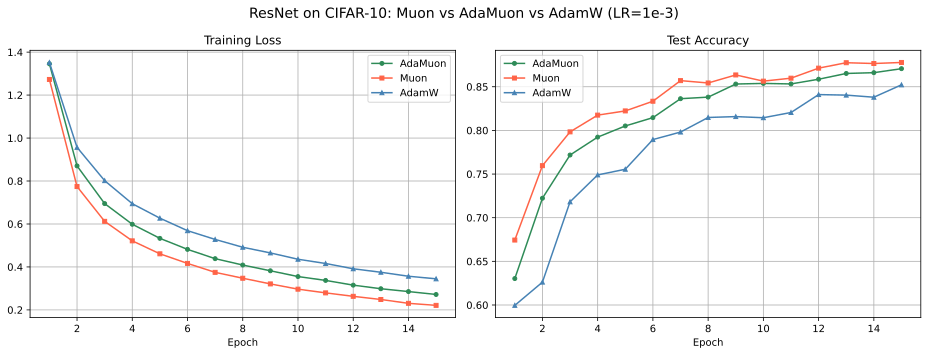

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

plt.suptitle(
    "ResNet on CIFAR-10: Muon vs AdaMuon vs AdamW (LR=1e-3)", fontsize=14)

x = np.arange(1, EPOCHS + 1)

ax1.plot(x, hist_adamuon["train_loss"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax1.plot(x, hist_muon["train_loss"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax1.plot(x, hist_adam["train_loss"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.grid()
ax1.legend()

ax2.plot(x, hist_adamuon["test_acc"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax2.plot(x, hist_muon["test_acc"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax2.plot(x, hist_adam["test_acc"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.grid()
ax2.legend()

plt.tight_layout()

In [79]:
EPOCHS = 30

In [80]:
hist_adamuon_100 = run("adamuon", num_classes=100,
                       epochs=EPOCHS, device=device)

/home/matta/dev/xpu/xpu_env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
100%|██████████| 40/40 [00:01<00:00, 27.84it/s]


[adamuon] epoch   1/30 loss=3.6076  test_acc=0.264


100%|██████████| 40/40 [00:01<00:00, 28.11it/s]


[adamuon] epoch   2/30 loss=2.6908  test_acc=0.362


100%|██████████| 40/40 [00:01<00:00, 28.58it/s]


...

[adamuon] epoch  28/30 loss=0.5985  test_acc=0.627


100%|██████████| 40/40 [00:01<00:00, 26.09it/s]


[adamuon] epoch  29/30 loss=0.5736  test_acc=0.621


100%|██████████| 40/40 [00:01<00:00, 27.43it/s]

[adamuon] epoch  30/30 loss=0.5529  test_acc=0.622


In [81]:
hist_muon_100 = run("muon", num_classes=100, epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 26.62it/s]


[muon] epoch   1/30 loss=3.4478  test_acc=0.312


100%|██████████| 40/40 [00:01<00:00, 29.09it/s]


[muon] epoch   2/30 loss=2.4228  test_acc=0.436


100%|██████████| 40/40 [00:01<00:00, 29.04it/s]


...

[muon] epoch  28/30 loss=0.4521  test_acc=0.644


100%|██████████| 40/40 [00:01<00:00, 26.77it/s]


[muon] epoch  29/30 loss=0.4259  test_acc=0.637


100%|██████████| 40/40 [00:01<00:00, 25.67it/s]

[muon] epoch  30/30 loss=0.4086  test_acc=0.637


In [82]:
hist_adam_100 = run("adam", num_classes=100, epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 27.15it/s]


[adam] epoch   1/30 loss=3.5940  test_acc=0.219


100%|██████████| 40/40 [00:01<00:00, 28.45it/s]


[adam] epoch   2/30 loss=2.8342  test_acc=0.294


100%|██████████| 40/40 [00:01<00:00, 28.66it/s]


...

[adam] epoch  28/30 loss=0.7673  test_acc=0.621


100%|██████████| 40/40 [00:01<00:00, 29.90it/s]


[adam] epoch  29/30 loss=0.7403  test_acc=0.618


100%|██████████| 40/40 [00:01<00:00, 28.77it/s]

[adam] epoch  30/30 loss=0.7201  test_acc=0.610


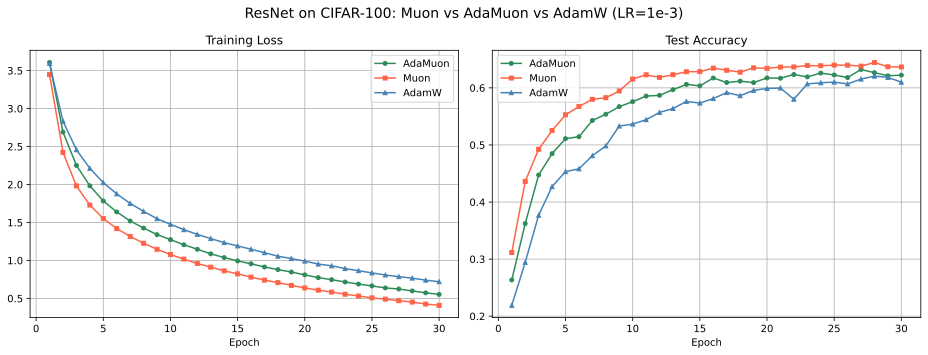

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

plt.suptitle(
    "ResNet on CIFAR-100: Muon vs AdaMuon vs AdamW (LR=1e-3)", fontsize=14)

x = np.arange(1, EPOCHS + 1)

ax1.plot(x, hist_adamuon_100["train_loss"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax1.plot(x, hist_muon_100["train_loss"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax1.plot(x, hist_adam_100["train_loss"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.grid()
ax1.legend()

ax2.plot(x, hist_adamuon_100["test_acc"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax2.plot(x, hist_muon_100["test_acc"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax2.plot(x, hist_adam_100["test_acc"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.grid()
ax2.legend()

plt.tight_layout()